Pulls data from API, filters for taxon_id 1280 = Staphylococcus aureus that was identified as resistant via wet lab. Then pull out datapoints that show resistance or susceptibility specifically to methicillin.

genome_amr API docs: https://www.bv-brc.org/api/doc/genome_amr

In [2]:
import requests
import pandas as pd
from io import StringIO

# The URL to pull Staph aureus, make sure that the resistance was tested in wet lab
url = "https://www.bv-brc.org/api/genome_amr/?eq(taxon_id,1280)&eq(evidence,Laboratory%20Method)&limit(50000)"
headers = {"Accept": "text/csv"}

# API request
response = requests.get(url, headers=headers)
df = pd.read_csv(StringIO(response.text))

# Filter to methicillin, only get the Resistant or susceptible genomes
methicillin_df = df[df['Antibiotic'] == 'methicillin'].copy()
methicillin_df = methicillin_df[methicillin_df['Resistant Phenotype'].isin(['Resistant', 'Susceptible'])]

# Get some information on the dataset that was pulled and filtered
print("Shape:", methicillin_df.shape)
print("\nClass balance:")
print(methicillin_df['Resistant Phenotype'].value_counts())
print("\nSample genome IDs:")
print(methicillin_df['Genome ID'].head(10).tolist())

# Save it
methicillin_df.to_csv("methicillin_labels.csv", index=False)
print("\nSaved methicillin_labels.csv")

Shape: (1082, 21)

Class balance:
Resistant Phenotype
Susceptible    574
Resistant      508
Name: count, dtype: int64

Sample genome IDs:
[1280.4727, 1280.8343, 1280.2483, 1280.8315, 1280.7953, 1280.25081, 1280.24873, 1280.2511, 1280.8168, 1280.9764]

Saved methicillin_labels.csv


In [3]:
# Take a look at data table
methicillin_df.head()

,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
17,1280,1280.4727,Staphylococcus aureus strain USFL197,methicillin,Resistant,NaN,NaN,NaN,NaN,Disk diffusion,...,NaN,NaN,CLSI,2013.0,NaN,NaN,NaN,Laboratory Method,NaN,29487865.0
20,1280,1280.8343,Staphylococcus aureus C00013400,methicillin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,26686880.0
142,1280,1280.2483,Staphylococcus aureus strain 12483_8_66,methicillin,Resistant,NaN,NaN,NaN,NaN,Broth dilution,...,VITEK 2,BioMerieux,British Society for Antimicrobial Chemotherapy...,NaN,NaN,NaN,NaN,Laboratory Method,NaN,30696529.0
143,1280,1280.8315,Staphylococcus aureus C00013372,methicillin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,26686880.0
152,1280,1280.7953,Staphylococcus aureus C00001155,methicillin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,26686880.0


Pull all gene results for the Genome_Ids that we collected

sp_gene API docs: https://www.bv-brc.org/api/doc/sp_gene

In [4]:
import requests
import pandas as pd
from io import StringIO

# Convert the genome IDs to a flat string that can be fed into an API call
genome_list = methicillin_df['Genome ID'].tolist()
genome_string = ",".join([str(x) for x in genome_list])

# Set up batches since there are a lot of genome IDs
all_batches = []
cursor = "*"

# Loop until all batches are completed
while True:
    # API request done in batches
    response = requests.post(
        "https://www.bv-brc.org/api/sp_gene/",
        headers={"Accept": "text/csv", "Content-Type": "application/rqlquery+x-www-form-urlencoded"},
        data=f'in(genome_id,({genome_string}))&eq(property,%22Antibiotic%20Resistance%22)&limit(25000)&cursor({cursor})'
    )

    # Convert the batch API call into a csv and then make into a DF. Append to final batch df
    batch_df = pd.read_csv(StringIO(response.text))
    all_batches.append(batch_df)

    # Save the next_cursor to know where to start for the next API call
    next_cursor = response.headers.get("X-Cursor-Mark")

    # Stop when cursor stops changing
    if next_cursor == cursor:
        break

    # update the Cursor and run the loop again
    cursor = next_cursor

genes_df = pd.concat(all_batches, ignore_index=True)
print(f"\nTotal records: {len(genes_df)}")
print(f"Unique genomes: {genes_df['Genome ID'].nunique()}")
print(f"\nTop 20 genes:")
print(genes_df['Gene'].value_counts().head(20))
print(f"\nmecA present: {'mecA' in genes_df['Gene'].values}")


Total records: 86803
Unique genomes: 980

Top 20 genes:
Gene
GdpD         902
gyrB         650
gyrA         647
rpoC         638
rpoB         638
MurA         600
blaZ         368
mgrA         357
arlS         341
folA, Dfr    339
mecR1        339
pgsA         338
mprF         338
arlR         338
mepA         338
dfrC         324
rho          321
folP         319
gidB         319
parE         319
Name: count, dtype: int64

mecA present: True


In [5]:
# Save raw genes
genes_df.to_csv("raw_genes.csv", index=False)
print("Saved raw_genes.csv")

print(f"\nmecA count: {genes_df['Gene'].value_counts()['mecA']}")
print(f"mecA rank: {list(genes_df['Gene'].value_counts().index).index('mecA') + 1}")

Saved raw_genes.csv

mecA count: 298
mecA rank: 50


Inspect the two tables

In [6]:
import pandas as pd

labels_df = pd.read_csv("../methicillin_labels.csv")
genes_df = pd.read_csv("../raw_genes.csv")

print("LABELS:")
print(labels_df.shape)
print(labels_df.columns.tolist())
print(labels_df.head())

print("\nGENES:")
print(genes_df.shape)
print(genes_df.columns.tolist())
print(genes_df.head())

LABELS:
(1082, 21)
['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'Measurement', 'Measurement Sign', 'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method', 'Laboratory Typing Method Version', 'Laboratory Typing Platform', 'Vendor', 'Testing Standard', 'Testing Standard Year', 'Computational Method', 'Computational Method Version', 'Computational Method Performance', 'Evidence', 'Source', 'PubMed']
   Taxon ID  Genome ID                              Genome Name   Antibiotic  \
0      1280  1280.4727     Staphylococcus aureus strain USFL197  methicillin   
1      1280  1280.8343          Staphylococcus aureus C00013400  methicillin   
2      1280  1280.2483  Staphylococcus aureus strain 12483_8_66  methicillin   
3      1280  1280.8315          Staphylococcus aureus C00013372  methicillin   
4      1280  1280.7953          Staphylococcus aureus C00001155  methicillin   

  Resistant Phenotype  Measurement  Measurement Sign  Measurement Value  

Inspect genes table for missing data.

In [7]:
import pandas as pd

genes_df = pd.read_csv("../raw_genes.csv")

print("Missing gene values:", genes_df['Gene'].isna().sum())
print("Unique gene names:", genes_df['Gene'].nunique())
print("\nSample of gene values:")
print(genes_df['Gene'].head(20).tolist())

Missing gene values: 66951
Unique gene names: 136

Sample of gene values:
[nan, 'TcaB', nan, nan, nan, nan, 'EF-Tu', nan, nan, nan, nan, 'BlaZ family', nan, 'rpoC', nan, nan, nan, nan, nan, nan]


Lots of missing data in genes table, look at product column for useful information about the gene

In [8]:
import pandas as pd

genes_df = pd.read_csv("../raw_genes.csv")

missing_gene = genes_df[genes_df['Gene'].isna()]

print("Shape of missing-gene rows:", missing_gene.shape)
print("\nSample rows with missing Gene:")
print(missing_gene[['Genome ID', 'Gene', 'Product', 'Classification', 'Source']].head(10))

Shape of missing-gene rows: (66951, 21)

Sample rows with missing Gene:
      Genome ID Gene                                            Product  \
0    1280.97810  NaN  Cell envelope stress response system LiaFSR, r...   
2    1280.97470  NaN                      Alanine racemase (EC 5.1.1.1)   
3    1280.98490  NaN                 DNA gyrase subunit B (EC 5.99.1.3)   
4    1280.87260  NaN  Two component system histidine kinase ArlS (EC...   
5   46170.17600  NaN          Cardiolipin synthase, bacterial type ClsA   
7    1280.96940  NaN  Cell envelope stress response system LiaFSR, r...   
8    1280.10026  NaN               Uncharacterized MFS-type transporter   
9    1280.25011  NaN                      Alanine racemase (EC 5.1.1.1)   
10   1280.83850  NaN             Isoleucyl-tRNA synthetase (EC 6.1.1.5)   
12   1280.24892  NaN  Beta-lactamase regulatory sensor-transducer BlaR1   

                                       Classification  Source  
0   regulator modulating expression of

Replace NA in genes column with product info, inspect column after.

In [9]:
import pandas as pd

genes_df = pd.read_csv("../raw_genes.csv")

# Use Gene where available, fall back to Product when Gene is missing
genes_df['feature_name'] = genes_df['Gene'].fillna(genes_df['Product'])

print("Missing after fallback:", genes_df['feature_name'].isna().sum())
print("Unique feature names:", genes_df['feature_name'].nunique())
print("\nSample feature names:")
print(genes_df['feature_name'].head(20).tolist())

Missing after fallback: 0
Unique feature names: 279

Sample feature names:
['Cell envelope stress response system LiaFSR, response regulator LiaR(VraR)', 'TcaB', 'Alanine racemase (EC 5.1.1.1)', 'DNA gyrase subunit B (EC 5.99.1.3)', 'Two component system histidine kinase ArlS (EC 2.7.3.-)', 'Cardiolipin synthase, bacterial type ClsA', 'EF-Tu', 'Cell envelope stress response system LiaFSR, response regulator LiaR(VraR)', 'Uncharacterized MFS-type transporter', 'Alanine racemase (EC 5.1.1.1)', 'Isoleucyl-tRNA synthetase (EC 6.1.1.5)', 'BlaZ family', 'Beta-lactamase regulatory sensor-transducer BlaR1', 'rpoC', 'Cell envelope stress response system LiaFSR, sensor histidine kinase LiaS(VraS)', 'Two-component sensor histidine kinase BceS', 'SmrB', '16S rRNA (guanine(527)-N(7))-methyltransferase (EC 2.1.1.170)', 'UDP-N-acetylglucosamine 1-carboxyvinyltransferase (EC 2.5.1.7)', 'Transcriptional regulator MgrA (Regulator of autolytic activity)']


Multi-hot encode the new feature name column

In [10]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# print(genes_df.head())
genome_genes = genes_df.groupby('Genome ID')['feature_name'].apply(list)

# genome_genes.head()

mlb = MultiLabelBinarizer()
encoded_genes = mlb.fit_transform(genome_genes)

df_encoded_genes = pd.DataFrame(encoded_genes, index = genome_genes.index,columns=mlb.classes_)

print("Shape:", df_encoded_genes.shape)
print(df_encoded_genes.iloc[:5, :5])

Shape: (980, 279)
            1-deoxy-D-xylulose 5-phosphate reductoisomerase (EC 1.1.1.267)  \
Genome ID                                                                    
1280.10002                                                  0                
1280.10003                                                  0                
1280.10004                                                  0                
1280.10005                                                  0                
1280.10007                                                  0                

            16S rRNA (guanine(527)-N(7))-methyltransferase (EC 2.1.1.170)  \
Genome ID                                                                   
1280.10002                                                  1               
1280.10003                                                  1               
1280.10004                                                  1               
1280.10005                                        

Merge encoded genes back onto labels table to get outcome

In [11]:
import pandas as pd

labels_df = pd.read_csv("../methicillin_labels.csv")

labels_df = labels_df.set_index("Genome ID")

dataset = df_encoded_genes.join(labels_df["Resistant Phenotype"], how="right")

print("Shape after right merge:", dataset.shape)
print("Missing gene values (before fill):", dataset.drop(columns='Resistant Phenotype').isna().sum().sum())

gene_cols = dataset.columns.drop("Resistant Phenotype")
dataset[gene_cols] = dataset[gene_cols].fillna(0)

print("\nShape after fill:", dataset.shape)
print("Missing values remaining:", dataset.isna().sum().sum())
print("\nClass balance:")
print(dataset['Resistant Phenotype'].value_counts())


Shape after right merge: (1082, 280)
Missing gene values (before fill): 28179

Shape after fill: (1082, 280)
Missing values remaining: 0

Class balance:
Resistant Phenotype
Susceptible    574
Resistant      508
Name: count, dtype: int64


Sanity check on the genomes that were missing genes, bit of a mixed bag.

In [12]:
# Sanity check: are zero-gene genomes mostly Susceptible?
zero_gene_mask = (dataset[gene_cols].sum(axis=1) == 0)
print(dataset[zero_gene_mask]['Resistant Phenotype'].value_counts())

Resistant Phenotype
Susceptible    57
Resistant      44
Name: count, dtype: int64


Create a train/test split on the dataset

In [13]:
from sklearn.model_selection import train_test_split

# print(dataset.head())

X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

y = y.replace({"Resistant" : 1, "Susceptible": 0}).astype(int)
# print(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify= y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Train shape: (865, 279)
Test shape: (217, 279)

Train class balance:
Resistant Phenotype
0    459
1    406
Name: count, dtype: int64

Test class balance:
Resistant Phenotype
0    115
1    102
Name: count, dtype: int64


Train Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
y_pred_proba = logreg_model.predict_proba(X_test)[:, 1]  # probability of class 1 (Resistant)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9447004608294931
F1 score: 0.9375
AUC: 0.9843989769820972

Confusion matrix:
[[115   0]
 [ 12  90]]


Good baseline model, has 12 false negatives. This is not ideal for clinical calls.

Look at the most important features

In [15]:
import pandas as pd

# Pair each feature name with its coefficient
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg_model.coef_[0]
})

# Sort by absolute value to get most influential features (positive or negative)
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print(coef_df.head(20))

                                               feature  coefficient  \
134  Penicillin-binding protein PBP2a, methicillin ...     3.029968   
120  Methicillin resistance regulatory sensor-trans...     2.746751   
63        DNA topoisomerase IV subunit A (EC 5.99.1.3)     1.537088   
121              Methicillin resistance repressor MecI     0.732126   
87                    Glycerol-3-phosphate transporter    -0.630878   
85                  Fosfomycin resistance protein FosB    -0.601864   
159  Tetracycline resistance, MFS efflux pump => Te...     0.553766   
43                        Bleomycin resistance protein     0.449016   
4    23S rRNA (adenine(2058)-N(6))-dimethyltransfer...     0.440812   
28   Aminoglycoside 4'-nucleotidyltransferase (EC 2...     0.313055   
64        DNA topoisomerase IV subunit B (EC 5.99.1.3)    -0.287316   
41                       Beta-lactamase repressor BlaI     0.250940   
40   Beta-lactamase regulatory sensor-transducer BlaR1     0.250940   
59   C

Horzontal Bar Chart showing features impact

In [16]:
coef_df.iloc[0:10,:]

,feature,coefficient,abs_coefficient
134,"Penicillin-binding protein PBP2a, methicillin ...",3.029968,3.029968
120,Methicillin resistance regulatory sensor-trans...,2.746751,2.746751
63,DNA topoisomerase IV subunit A (EC 5.99.1.3),1.537088,1.537088
121,Methicillin resistance repressor MecI,0.732126,0.732126
87,Glycerol-3-phosphate transporter,-0.630878,0.630878
85,Fosfomycin resistance protein FosB,-0.601864,0.601864
159,"Tetracycline resistance, MFS efflux pump => Te...",0.553766,0.553766
43,Bleomycin resistance protein,0.449016,0.449016
4,23S rRNA (adenine(2058)-N(6))-dimethyltransfer...,0.440812,0.440812
28,Aminoglycoside 4'-nucleotidyltransferase (EC 2...,0.313055,0.313055


C:\Users\Max\AppData\Local\Temp\ipykernel_18348\3596792713.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


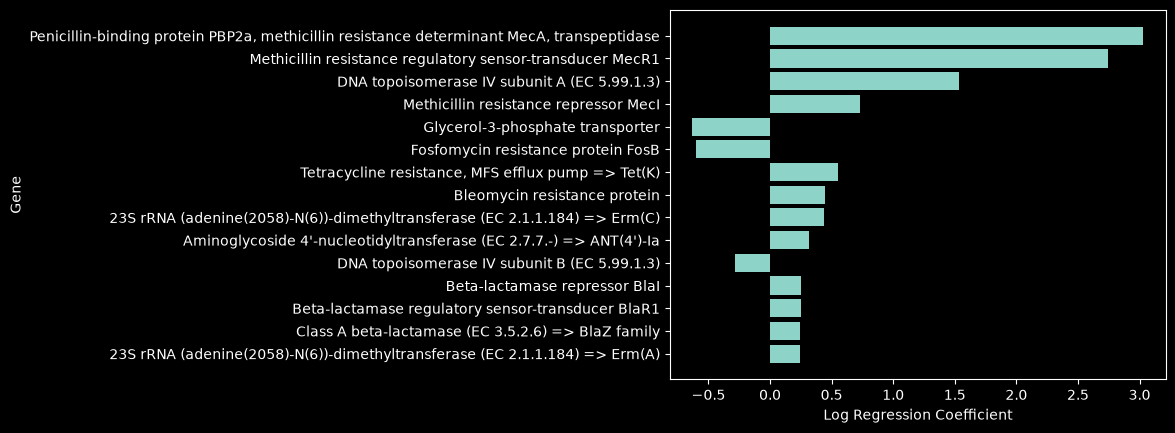

In [17]:
import matplotlib.pyplot as plt

top = coef_df.iloc[0:15,:]

plt.barh(top['feature'], top['coefficient'])

plt.xlabel('Log Regression Coefficient')
plt.ylabel('Gene')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Run an XGboost model on same dataset.

In [18]:
import re

# Remove [, ], and < from column names
X_train.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_test.columns]


In [19]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=1000,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=0
)

xgboost_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgboost_model.best_iteration}")

Best iteration: 44


In [20]:
y_pred_xg = xgboost_model.predict(X_test)
y_pred_proba_xg = xgboost_model.predict_proba(X_test)[:, 1]  # probability of class 1 (Resistant)

print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("F1 score:", f1_score(y_test, y_pred_xg))
print("AUC:", roc_auc_score(y_test, y_pred_proba_xg))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_xg))

Accuracy: 0.9447004608294931
F1 score: 0.9375
AUC: 0.9810741687979538

Confusion matrix:
[[115   0]
 [ 12  90]]


In [21]:
import numpy as np

# Are the predictions identical row-by-row?
same_predictions = (y_pred == y_pred_xg)
print("Predictions match:", same_predictions.sum(), "out of", len(y_pred))
print("Percent identical:", same_predictions.mean() * 100)

# Are the predicted probabilities identical too?
print("\nMax probability difference:", np.abs(y_pred_proba - y_pred_proba_xg).max())

Predictions match: 217 out of 217
Percent identical: 100.0

Max probability difference: 0.02965573991017434


Both logistic regression and XGBoost converged on identical classifications, differing only marginally in predicted probabilities. This suggests the genetic signal for methicillin resistance. Primarily driven by mecA-associated genes is strong and close to linearly separable, rather than requiring complex non-linear interactions to detect.

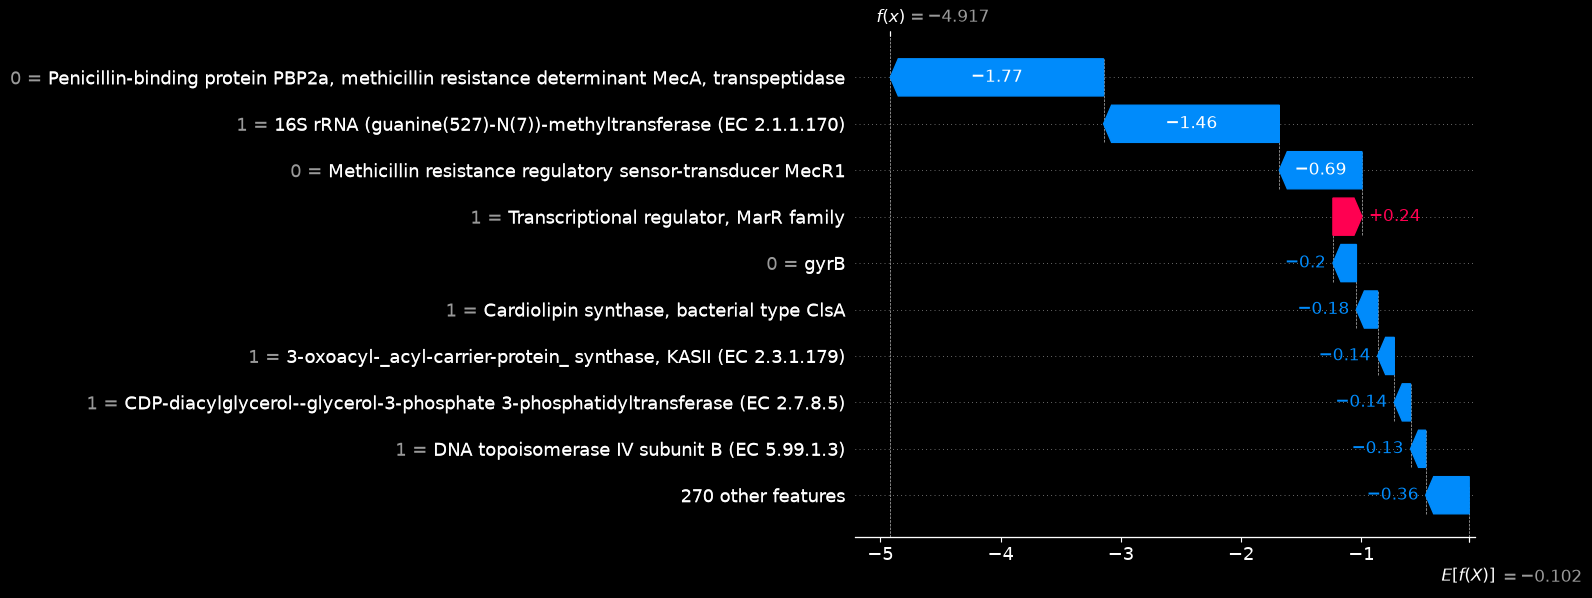

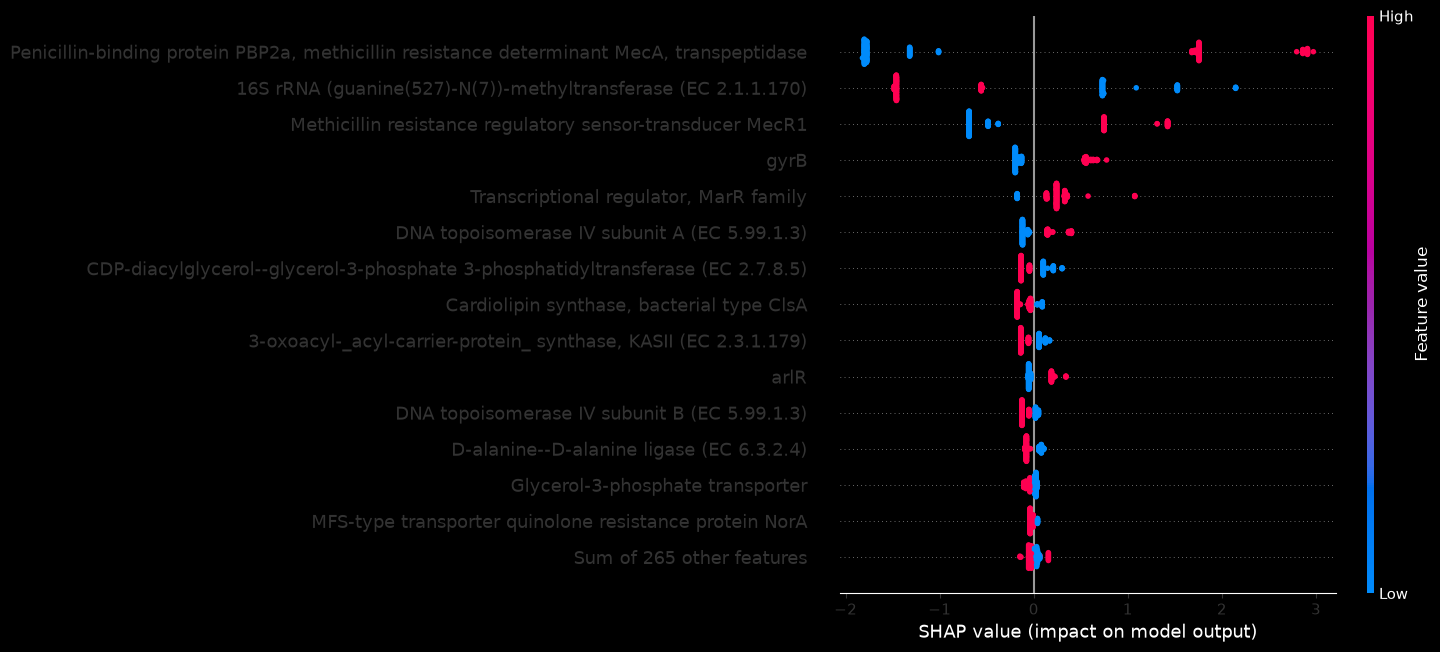

In [22]:
import shap

#Initialize TreeExplainer and Compute SHAP Values
explainer = shap.TreeExplainer(xgboost_model)
shap_values = explainer(X_test)

# Visualize Results
shap.plots.waterfall(shap_values[0])

# Plot B: Summarize global feature importance across the entire test set
shap.plots.beeswarm(shap_values, max_display=15)

In [23]:
import sys
print(sys.executable)

import numpy
print(numpy.__version__)

C:\Users\Max\AppData\Local\Python\pythoncore-3.14-64\python.exe
2.4.6


In [24]:
# Find which row this is and whether it was misclassified
idx = 0  # the index you used in shap_values[0]
genome_id = X_test.index[idx]
actual = y_test.iloc[idx]
predicted = y_pred_xg[idx]

print(f"Genome ID: {genome_id}")
print(f"Actual: {'Resistant' if actual == 1 else 'Susceptible'}")
print(f"Predicted: {'Resistant' if predicted == 1 else 'Susceptible'}")

Genome ID: 1280.8162
Actual: Susceptible
Predicted: Susceptible


Find a list of the 12 false negatives from the model

In [25]:
y_test.iloc[[0]]
miss_match_list = []

for i in range(0,len(y_test)):
    if y_test.iloc[i] != y_pred_xg[i]:
        row_dict = {'Genome ID': y_test.index[i], 'Resistant Phenotype': y_test.iloc[i], 'y_pred': y_pred_xg[i]}
        miss_match_list.append(row_dict)

fn_df = pd.DataFrame(miss_match_list)
print("Number of misclassified genomes:", len(fn_df))
print(fn_df)

Number of misclassified genomes: 12
    Genome ID  Resistant Phenotype  y_pred
0   1280.2514                    1       0
1   1280.2507                    1       0
2   1280.9910                    1       0
3   1280.1000                    1       0
4   1280.2499                    1       0
5   1280.9420                    1       0
6   1280.8510                    1       0
7   1280.2494                    1       0
8   1280.8774                    1       0
9   1280.2503                    1       0
10  1280.4346                    1       0
11  1280.2505                    1       0


SHAP on one of the false negative model calls

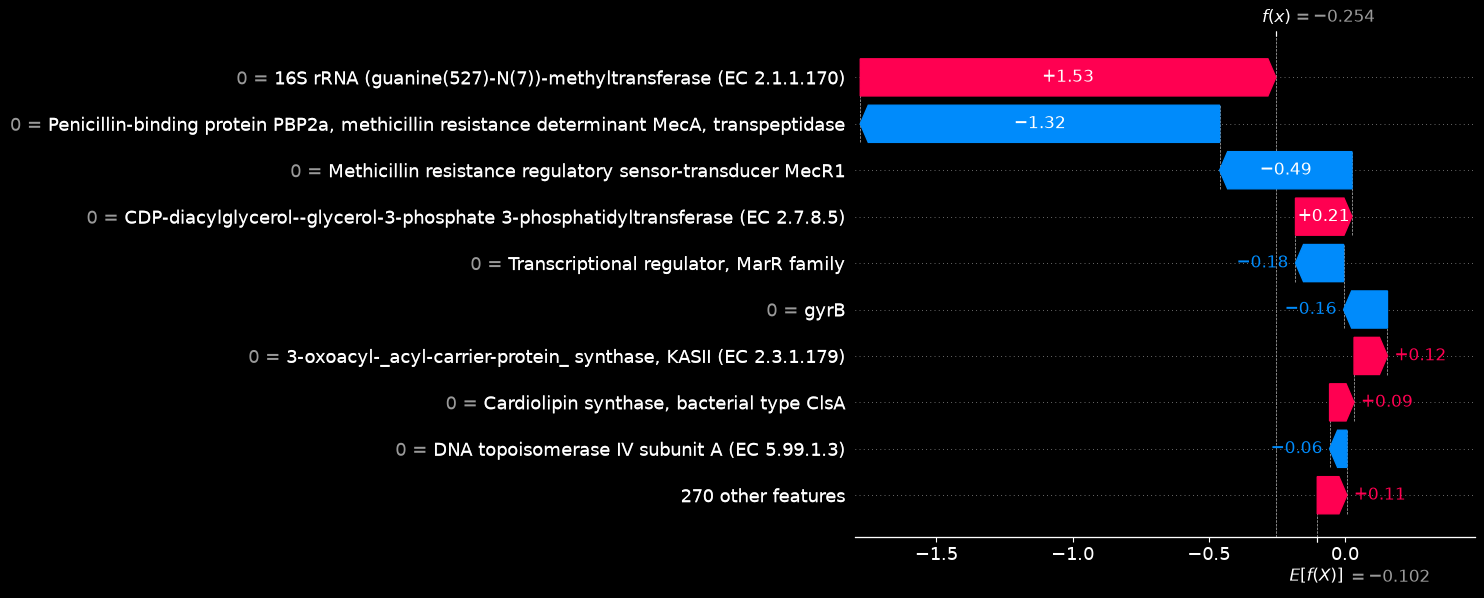

In [27]:
# Pick one misclassified genome ID
target_genome = fn_df['Genome ID'].iloc[0]

# Find its position in X_test
idx = X_test.index.get_loc(target_genome)

shap.plots.waterfall(shap_values[idx])

The model's most informative error was a genome predicted Susceptible despite being phenotypically Resistant. SHAP analysis showed this prediction was driven by the simultaneous absence of every annotated resistance gene in the panel including mecA. Rather than reflecting flawed reasoning, this likely points to a resistance mechanism not captured by current gene annotations, such as a structural mutation or an unannotated SCCmec element. This highlights a real limitation of gene-presence-based prediction: it can only detect resistance mechanisms that have already been catalogued.

In [28]:
# Check if we already have the genome name from our earlier genes_df
genome_name_lookup = genes_df[genes_df['Genome ID'] == '1280.2514']['Genome Name'].unique()
print(genome_name_lookup)

amr_df_check = labels_df[labels_df.index == 1280.2514] if labels_df.index.name == 'Genome ID' else None
print(amr_df_check)

<ArrowStringArray>
[]
Length: 0, dtype: str
           Taxon ID                              Genome Name   Antibiotic  \
Genome ID                                                                   
1280.2514      1280  Staphylococcus aureus strain 12673_8_61  methicillin   

          Resistant Phenotype  Measurement  Measurement Sign  \
Genome ID                                                      
1280.2514           Resistant          NaN               NaN   

           Measurement Value  Measurement Unit Laboratory Typing Method  \
Genome ID                                                                 
1280.2514                NaN               NaN           Broth dilution   

           Laboratory Typing Method Version Laboratory Typing Platform  \
Genome ID                                                                
1280.2514                               NaN                    VITEK 2   

               Vendor                                   Testing Standard  \
Genome